In [1]:
%load_ext cuml.accel
# %run /workspace/alvin/SAR_ML/notebooks/SSR/S2/SSRtransforms_all.py
%run /mnt/d/Users/Admin/Projects/dso/SAR_ML/notebooks/SSR/SSRtransforms_updated.py
import os
import random
from collections import defaultdict
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import CosineAnnealingLR, OneCycleLR
from torch.utils.data import DataLoader, ConcatDataset, Subset
import re
import copy
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap.umap_ as umap

2026-03-26 17:41:55.030859: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-26 17:41:55.105786: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-26 17:41:56.159194: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-26 17:41:56.161978: I external/local_xla/xla/tsl/cuda/cudart

In [2]:
# workspace = "/workspace/alvin/SAR_ML"
workspace = "/mnt/d/Users/Admin/Projects/dso/SAR_ML"
data_workspace = os.path.join(workspace, "data/SAMPLE")
clutter_dir = os.path.join(workspace, "data/MSTAR/CLUTTER/15_DEG")

In [3]:
gmm_cache = build_gmm_cache(input_dir = os.path.join(data_workspace, "mat_files/synth"), processing_func = LogMapping(c = 1000.0))

Found 1345 .mat files


Fitting GMMs: 100%|█████████████████████████████████████████████████████████████████| 1345/1345 [02:40<00:00,  8.40it/s]


In [4]:
synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), SSRAugmentation(gmm_cache, alpha=0.6, beta=0.4, apply_prob=0.5, gaussian_noise = True, mu_s = 0.0, sigma_s = 0.3), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

meas_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

In [5]:
meas_ds_path = [meas_ds.samples[i][0] for i in range(len(meas_ds))]
clutter_bright = {file: (os.path.join(clutter_dir, 'HB06158'), 1200, 1200) for file in meas_ds_path}
clutter_dark = {file: (os.path.join(clutter_dir, 'HB06158'), 100, 100) for file in meas_ds_path}
clutter_mixed = {file: (os.path.join(clutter_dir, 'HB06158'), 200, 280) for file in meas_ds_path}

In [6]:
meas_ds_bright = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), Scenario2Merging(clutter_bright), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

meas_ds_dark = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), Scenario2Merging(clutter_dark), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

meas_ds_mixed = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), Scenario2Merging(clutter_mixed), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

In [7]:
class_indices = defaultdict(list)
for idx, (path, label) in enumerate(meas_ds_bright.samples):
    class_indices[label].append(idx)

# Take first 2 from each class
selected_indices = []
for label, indices in class_indices.items():
    selected_indices.extend(indices[:2])

meas_ds_bright_sub = Subset(meas_ds_bright, selected_indices)
meas_ds_dark_sub = Subset(meas_ds_dark, selected_indices)
meas_ds_mixed_sub = Subset(meas_ds_mixed, selected_indices)

In [13]:
n_per_group = len(meas_ds_bright_sub)

In [8]:
sub_ds = ConcatDataset([meas_ds_bright_sub, meas_ds_dark_sub, meas_ds_mixed_sub])
test_ds = ConcatDataset([synth_ds, sub_ds])

In [9]:
# After extracting all features from test_ds (synth + sub_ds)
n_synth = len(synth_ds)
n_new = len(sub_ds)  # your new measured samples

# The new samples are at the end of test_ds
new_indices = list(range(n_synth, n_synth + n_new))

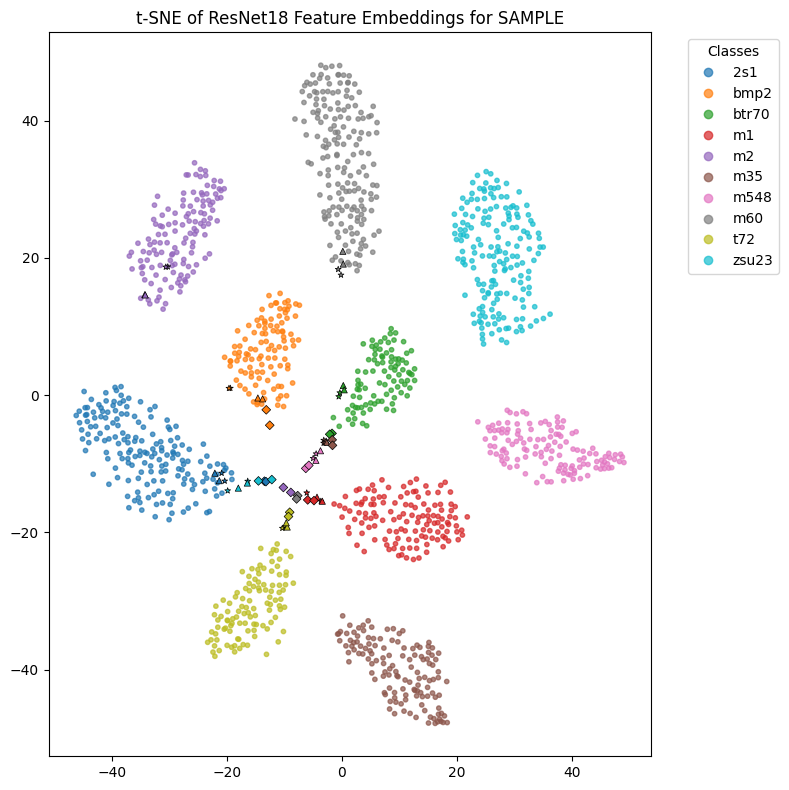

In [18]:
seed = 42
device = torch.cuda.set_device("cuda:0")
new_model = models.resnet18(weights = None) # dont load ImageNet Weights
# new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(synth_ds.class_to_idx))
    )
# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Experiment_1/SSR_exp1_full_runs/rn18_seed{seed}_b16.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

feature_extractor = nn.Sequential(*list(new_model.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

features, labels_list = [], []

with torch.no_grad():
    for inputs, targets in DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=12, pin_memory = True, persistent_workers=True):
        inputs = inputs.to(device)
        feats = feature_extractor(inputs)
        feats = feats.view(feats.size(0), -1)
        features.append(feats.cpu())
        labels_list.append(targets)

features = torch.cat(features).numpy()
labels_list = torch.cat(labels_list).numpy()

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    n_jobs=-1
)

features_2d = tsne.fit_transform(features)

# Get class names from the dataset
class_names = [name for name, idx in sorted(synth_ds.class_to_idx.items(), key=lambda x: x[1])]

# Overlay the 3 clutter variants with big distinct markers
clutter_labels = ["bright", "dark", "mixed"]
markers = ["*", "^", "D"]

n_classes = len(class_names)

plt.figure(figsize=(8, 8))

scatter = plt.scatter(
    features_2d[:n_synth, 0],
    features_2d[:n_synth, 1],
    c=labels_list[:n_synth],
    cmap="tab10",
    s=10,
    alpha=0.7,
    vmin=0, vmax=n_classes - 1  # lock colormap
)

for i, (label, marker) in enumerate(zip(clutter_labels, markers)):
    idx = n_synth + i * n_per_group
    plt.scatter(
        features_2d[idx:idx+n_per_group, 0],
        features_2d[idx:idx+n_per_group, 1],
        marker=marker,
        c=labels_list[idx:idx+n_per_group],
        cmap="tab10",
        s=20,
        label=f"measured ({label} clutter)",
        edgecolors="black",
        linewidths=0.5,
        zorder=5,
        vmin=0, vmax=n_classes - 1  # same lock
    )

plt.legend(
    handles=scatter.legend_elements()[0],
    labels=class_names,
    title="Classes",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.title("t-SNE of ResNet18 Feature Embeddings for SAMPLE")
plt.tight_layout()
plt.show()